# Convolution Neural Network in Pytorch

In [1]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
print("import success")

import success


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
import os

cores = os.cpu_count()
print(cores)

20


## Loading Data

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

BATCH_SIZE = 2048

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

c:\Users\Yong Rui\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
image, label = train_data[0]

In [7]:
image.size()

torch.Size([3, 32, 32])

In [8]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## Creating CNN

In [9]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout_conv = nn.Dropout(0.2)
        self.dropout_fc = nn.Dropout(0.4)

        self.fc1 = nn.Linear(256 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output= nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout_conv(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.dropout_conv(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = F.relu(self.fc2(x))
        x = self.dropout_fc(x)
        x = self.output(x)
        return x

In [10]:
net = NeuralNet().to(device)
loss_function = nn.CrossEntropyLoss()
optimiser = optim.Adam(net.parameters(), lr=0.001)

## Training Model

In [11]:
for epoch in range(50):
    print(f'Training epoch {epoch}...')

    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimiser.zero_grad()

        outputs = net(inputs)

        loss = loss_function(outputs, labels)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    print(f'Loss: {running_loss / len(train_loader):.4f}')

Training epoch 0...
Loss: 2.1764
Training epoch 1...
Loss: 1.8755
Training epoch 2...
Loss: 1.6564
Training epoch 3...
Loss: 1.5113
Training epoch 4...
Loss: 1.4133
Training epoch 5...
Loss: 1.3257
Training epoch 6...
Loss: 1.2367
Training epoch 7...
Loss: 1.1664
Training epoch 8...
Loss: 1.1088
Training epoch 9...
Loss: 1.0519
Training epoch 10...
Loss: 1.0036
Training epoch 11...
Loss: 0.9781
Training epoch 12...
Loss: 0.9340
Training epoch 13...
Loss: 0.8937
Training epoch 14...
Loss: 0.8539
Training epoch 15...
Loss: 0.8267
Training epoch 16...
Loss: 0.7996
Training epoch 17...
Loss: 0.7613
Training epoch 18...
Loss: 0.7352
Training epoch 19...
Loss: 0.7072
Training epoch 20...
Loss: 0.6789
Training epoch 21...
Loss: 0.6721
Training epoch 22...
Loss: 0.6405
Training epoch 23...
Loss: 0.6115
Training epoch 24...
Loss: 0.5878
Training epoch 25...
Loss: 0.5697
Training epoch 26...
Loss: 0.5431
Training epoch 27...
Loss: 0.5234
Training epoch 28...
Loss: 0.5020
Training epoch 29...
Los

### Saving Weights to Reuse

In [12]:
torch.save(net.state_dict(), 'trained_net.pth')

In [13]:
net = NeuralNet()
net.load_state_dict(torch.load('trained_net.pth'))
net.to(device)

NeuralNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.2, inplace=False)
  (dropout_fc): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
)

## Model Evaluation

In [14]:
correct = 0
total = 0

net.eval()

with torch.no_grad():
    for data in test_loader:
        images, labels = data
    
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy}%')

Accuracy: 79.26%


## Trying with New Data

In [15]:
new_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def load_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = new_transform(image)
    image = image.unsqueeze(0)
    return image

image_paths = ['dog.jpg', 'plane.jpg', 'cat.jpg']
images = [load_image(img) for img in image_paths]

net.to('cpu')

net.eval()
with torch.no_grad():
    for image in images:
        output = net(image)
        _, predicted = torch.max(output, 1)
        print(f'Prediction: {class_names[predicted.item()]}')

Prediction: dog
Prediction: plane
Prediction: bird


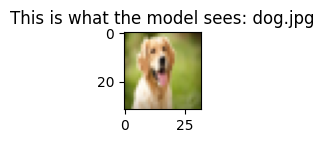

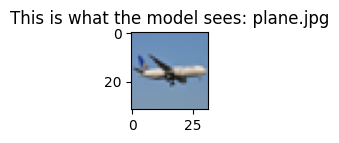

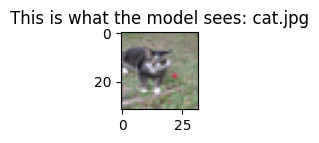

In [16]:
import matplotlib.pyplot as plt

def check_what_model_sees(image_path):
    # Open and resize exactly like your pipeline does
    img = Image.open(image_path).convert('RGB').resize((32, 32))
    plt.figure(figsize=(1,1)) # Force it to show at actual tiny scale
    plt.imshow(img)
    plt.title(f"This is what the model sees: {image_path}")
    plt.show()

for img in image_paths:
    check_what_model_sees(img)